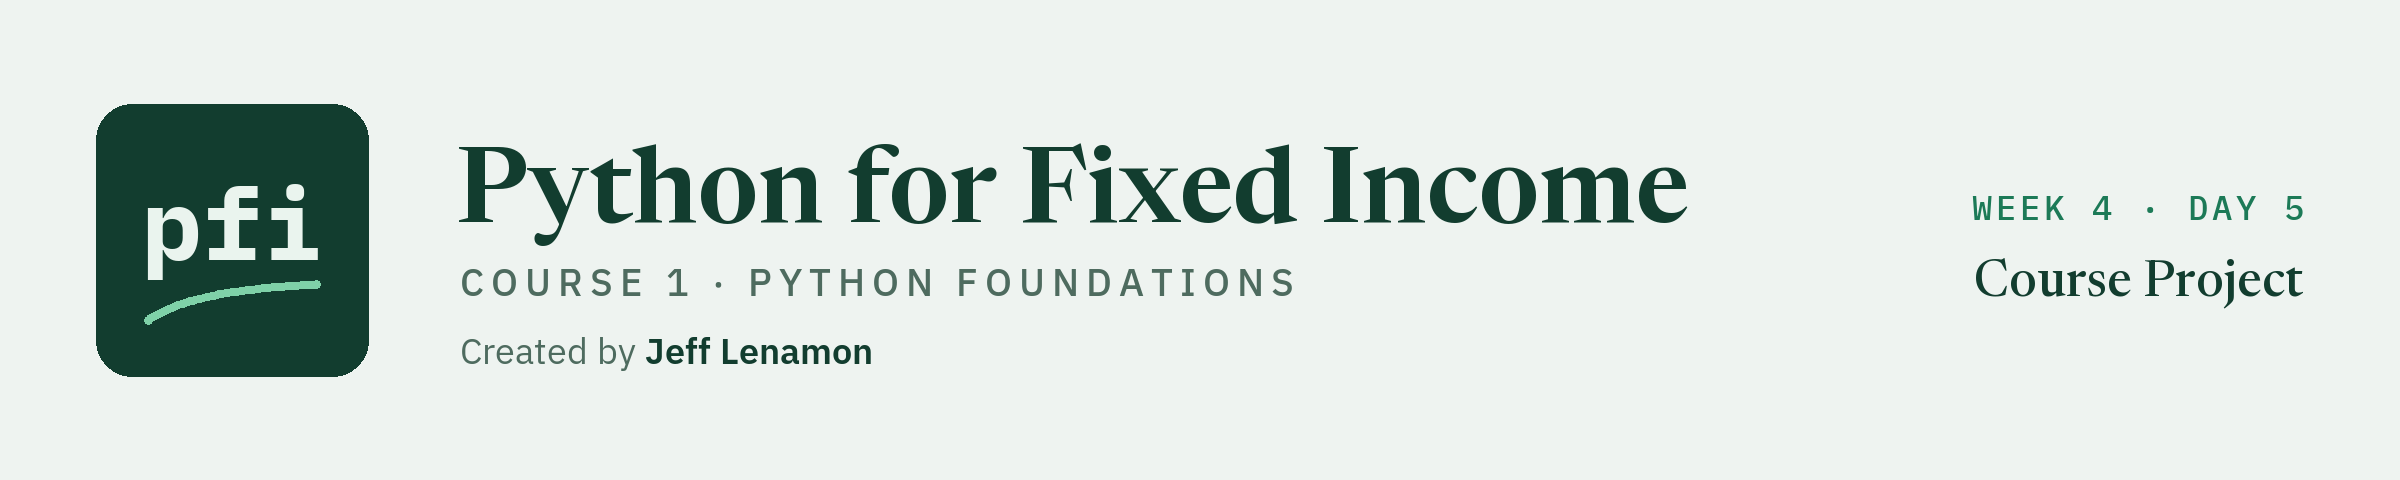

# Course Project

Week 4, day 5. A new month-end extract is tested against its cover note and the desk's rules, cleaned by a function you write, summarized, charted, compared with its benchmark, and written up for the portfolio manager. You write the code.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day5/course1_project.ipynb)

## The brief

### The scenario

It is month end. You are the analyst on the credit desk, and the operations team has sent the holdings extract for 2026-10-30 with a cover note. The portfolio manager wants a written picture of the book before the month-end meeting: what is in it, where it is concentrated, whether the file can be trusted, and how the book differs from its benchmark.

This is the same desk and the same kind of extract as week 3, one month later. It is a new file. What was wrong with the September extract tells you nothing about what is wrong with this one. Run the routine, do not remember it.

Everything in the files is invented: the issuers, the tickers, the CUSIPs, the prices, and the positions. No name here refers to a real company.

### The cover note

```
To: Credit desk
From: Operations
Subject: Month-end holdings extract, as of 2026-10-30

The month-end extract is attached as project_holdings.csv.

Control totals for the book:
  Number of bonds:      206
  Total face:           507,250,000 dollars
  Total market value:   509,928,477.50 dollars

Market value is face times clean price plus accrued interest, divided by 100.
All positions are priced as of 2026-10-30.
Please tell us if the extract does not agree with these totals.
```

The note is also in the course repo as `data/project_cover_note.txt`.

### What to hand in

This notebook, completed and run from top to bottom, with:

* every code cell filled in and every decision written down;
* the function `clean_extract` of question 4.2, with its `assert` checks against the cover note;
* the Excel workbook of question 9.1, which the notebook writes, reads back, and deletes, so there is no second file to send;
* the AI-use log of question 9.2;
* the written conclusion of question 9.3.

### How long

The course map gives the project one day: week 4, day 5. It is more work than one sitting. Plan on two or three.

| Sitting | Sections |
| --- | --- |
| First | 1 structure, 2 data types, 3 testing the extract, 4 the fixes and the cleaning function |
| Second | 5 summary statistics, 6 one column at a time, 7 two or more columns |
| Third | 8 the desk's questions, 9 the workbook, the AI-use log, and the conclusion |

The first sitting ends with a table you trust and a function that rebuilds it. The other two describe the table.

### The rules

1. **Work in a copy.** `raw` is the file as it arrived and is never changed. Question 2.2 makes the working copy, `book`, and every fix is made to `book`.
2. **State every decision.** Before each fix, add a markdown cell that says what you are changing, in how many rows, and what evidence in the files supports it.
3. **Print the headline numbers before and after every fix.** The setup cell gives you `headline()` for that.
4. **Describe, never recommend.** Every sentence you write says what the data shows. Nothing recommends, ranks, or forecasts a bond, an issuer, or a sector.
5. **Charts are finished charts.** A title, a label on each axis, and the unit.
6. **The notebook runs from top to bottom** with Restart and Run All before you hand it in.

### What help is allowed

* Every earlier notebook of the course, and your own notes.
* The documentation of pandas, matplotlib, and seaborn.
* An AI assistant, used the way the course taught: read the code it gives you, predict what it will print, run it, and check the result against a number you worked out yourself or against a control total. An answer you cannot check is not finished. Nothing from an employer goes into an AI tool or into Colab. The course data is synthetic for that reason. Keep a note of what you ask as you go: question 9.2 asks for a log.

### How to check your work

Most questions ask you to store an answer in a variable such as `answer_3_2`. The cell after it calls `check()`, which prints `correct`, `not yet` with what you have, or `not attempted yet`.

The right answers are not written anywhere in this notebook. Each check holds a short code made from the right answer, and `check()` makes a code from your answer in the same way and compares the two. A whole number can be given as `7` or `7.0`. A decimal is rounded to the number of places the question states before it is compared, so give your answer to at least that many places. Text is compared without regard to capitals or spaces at the ends.

A check tests the number. It does not test your reasoning, and charts and written answers have no check: each of those questions says what a good answer includes.

Your cleaning decisions change the numbers that follow. After question 4.1 there is a checkpoint cell that tests your cleaned table against the cover note and against the decisions the worked version made. Do not go on to section 5 until it passes. A different decision can be defensible. If you make one, say so in a markdown cell and expect the checks to disagree from there on.

Worked answers are in `course1_project_solutions.ipynb` in this folder. Open it after you have written your own conclusion.

## The data

Three files. Units: **`coupon` and `yield_pct` are in percent, `oas` is in basis points, `duration` is in years, `price` and `accrued` are per 100 of face, and `par_held`, `amount_outstanding`, and `market_value` are in dollars.**

**`project_holdings.csv`**: the extract. One row should be one bond the desk holds.

| Column | Meaning | Units |
| --- | --- | --- |
| `as_of_date` | the date the book is valued | year-month-day |
| `cusip` | the bond's identifier, nine characters | text |
| `ticker` | the issuer's ticker, four capital letters | text |
| `issuer` | the issuer's name | text |
| `sector` | the sector, a name from the benchmark's list | text |
| `rating` | the bond's rating, from AAA to CCC | text |
| `coupon` | annual coupon rate | percent |
| `maturity` | the date the bond repays | year-month-day |
| `price` | clean price | per 100 of face |
| `price_date` | the date of the price | year-month-day |
| `accrued` | accrued interest | per 100 of face |
| `yield_pct` | yield to maturity | percent |
| `oas` | option-adjusted spread, a whole number | basis points |
| `duration` | modified duration | years |
| `spread_duration` | spread duration, equal to the duration for these bonds | years |
| `dts` | duration times spread: spread duration times OAS, to one decimal place | years times basis points |
| `amount_outstanding` | face of the whole issue | dollars |
| `par_held` | face the desk holds | dollars |
| `market_value` | face held times (price plus accrued), divided by 100 | dollars |

**`ratings.csv`**: the rating scale, 18 rows. `rating`, `score` (1 for AAA up to 18 for CCC, so a higher score is a lower rating), `bucket` (the rating without its plus or minus), and `grade` (Investment Grade or High Yield).

**`benchmark.csv`**: the benchmark the book is measured against, 821 bonds. It has the same columns as the extract with two differences: there is no `par_held`, and there is a `weight_pct` column, the weight of each bond in the benchmark in percent. Its `market_value` is that of the whole issue. **The benchmark file is the September file, as of 2026-09-30.** The desk has not been sent an October one. In this project the book is compared with it by sector weights and by rating bucket weights only, and the conclusion says that the two files are a month apart.

## Setup

Run this cell first. It is complete: do not change it. It imports the libraries, loads the three files, stores the control totals from the cover note, and defines three helpers: `headline()`, which prints the headline numbers of a table, and `answer_text()` and `check()`, which mark your answers without showing the right ones. It prints the shapes of the rating scale and the benchmark. The shape of the extract is yours to find.

In [1]:
# hashlib makes the short codes that check() compares. os finds the data folder and deletes files.
import hashlib
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/project_holdings.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# raw is the extract exactly as it arrived. Nothing you write should change it.
raw = pd.read_csv(data_folder + 'project_holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')

# the control totals from the cover note
expected_bonds = 206
expected_face = 507_250_000
expected_value = 509_928_477.50


def headline(label, table):
    # the headline numbers, to print before and after every fix
    print(label)
    print(f'   rows: {len(table):,}')
    print(f"   face: {table['par_held'].sum():,} dollars")
    print(f"   market value: {table['market_value'].sum():,.2f} dollars")
    print(f"   mean OAS: {table['oas'].mean():.2f} basis points")


# The right answers are not written in this notebook, so that no check can be read before the work is done.
# Each check holds a short code made from the right answer, and check() makes a code from yours the same way.
def answer_text(answer, places):
    """Write an answer as text in one standard form, so that 7, 7.0, and a numpy 7 all read the same."""
    if isinstance(answer, str):
        # text: spaces at the ends and capital letters do not matter
        return answer.strip().lower()
    if isinstance(answer, (tuple, list)):
        # a pair of numbers: each one in turn
        return ','.join(answer_text(item, places) for item in answer)
    # a number: rounded to the places the question asks for. Adding 0.0 turns -0.0 into 0.0.
    number = round(float(answer), places) + 0.0
    return f'{number:.{places}f}'


def check(label, answer, code, places=0):
    """Make a short code from an answer, compare it with the stored code, and print the result."""
    if answer is ...:
        print(f'{label}: not attempted yet')
        return
    try:
        text = answer_text(answer, places)
    except (TypeError, ValueError):
        print(f'{label}: not yet. The answer should be a number, a piece of text, or a pair of numbers')
        return
    # the first 12 characters of the SHA-256 hash of the label and the answer
    found = hashlib.sha256(f'{label}|{text}'.encode()).hexdigest()[:12]
    if found == code:
        print(f'{label}: correct')
    else:
        print(f'{label}: not yet. You have {answer}. Check the rounding the question asks for.')


print(f'Loaded raw, ratings {ratings.shape}, and benchmark {benchmark.shape}')

Loaded raw, ratings (18, 4), and benchmark (821, 19)


## 1 The structure of the data

### 1.1 Rows and columns

Q. How many rows and columns does the extract have? Store the shape, a pair of numbers (rows, columns), in **answer_1_1**, and show the first five rows. In a sentence, say what one row of this file is.

In [2]:
# your code here
answer_1_1 = ...

In [3]:
check('Question 1.1', answer_1_1, '05e0296b84e8')

Question 1.1: not attempted yet


### 1.2 Identifiers and dates

Q. How many different as-of dates, CUSIPs, tickers, and issuer names are in the file? Store the number of different CUSIPs in **answer_1_2**.

In [4]:
# your code here
answer_1_2 = ...

In [5]:
check('Question 1.2', answer_1_2, 'd52f49f181ed')

Question 1.2: not attempted yet


## 2 Data types

### 2.1 The type of each column

Q. What type did pandas give each column? Count the columns held as numbers and store the count in **answer_2_1**. In a sentence, say which columns hold dates and what type they have.

In [6]:
# your code here
answer_2_1 = ...

In [7]:
check('Question 2.1', answer_2_1, '4c24a69566ad')

Question 2.1: not attempted yet


### 2.2 A working copy with real dates

Q. Make a working copy of `raw` called `book`, and convert its three date columns to dates. Count the dates that could not be read, over the three columns, and store the count in **answer_2_2**. Print the earliest and the latest value of each date column.

From here on every fix is made to `book`, and `raw` stays as it arrived.

In [8]:
# your code here
book = ...
answer_2_2 = ...

In [9]:
check('Question 2.2', answer_2_2, '08e885e49d35')

Question 2.2: not attempted yet


## 3 Data quality: test the extract

There is no list of what is wrong with this file. There is the cover note, and there are the rules the desk expects every extract to meet.

**The brief: test this extract against its cover note and the rules below. Fix what is an error, flag what you cannot fix, keep what is real.**

| Rule | What the desk expects of an extract |
| --- | --- |
| 1 | One row for each bond held. No row is a copy of another |
| 2 | Identifiers are well formed and unique. A CUSIP is nine characters, each a capital letter or a digit, and appears once |
| 3 | The face held is positive |
| 4 | The maturity is after the as-of date |
| 5 | Market value equals face times (price plus accrued), divided by 100, to within 1 dollar |
| 6 | Sector names are the names in the benchmark's list |
| 7 | No number is missing |

The cover note adds claims of its own: the three control totals, and that every position is priced as of 2026-10-30.

Section 3 is for finding. Each question tests one rule or one claim and asks how many rows fail it. **Count on `book` as question 2.2 left it, and fix nothing yet.** A rule that every row passes is a result too, and it goes in your write-up beside the rules that failed. Section 4 is for deciding and fixing.

Under some questions there is a closed block that starts "Stuck after trying?". It holds the decision that the checkpoint in section 4 expects for one kind of problem. Leave it closed until you have made your own decision. Open it if the checkpoint disagrees with you and you cannot see why.

### 3.1 The file against the cover note

Q. Print the headline numbers of the extract as received. Then print the difference between the file and the cover note, file less cover note, for the number of rows, the total face, and the total market value. Store the difference in rows in **answer_3_1**. In a sentence, say what the three differences suggest.

In [10]:
# your code here
answer_3_1 = ...

In [11]:
check('Question 3.1', answer_3_1, 'f3aa83b30526')

Question 3.1: not attempted yet


### 3.2 Rule 1: one row for each bond

Q. How many rows of `book` are an exact copy of an earlier row? Store the count in **answer_3_2**. If there are any, show each copy next to the row it repeats, and print the face and the market value that the copies carry.

In [12]:
# your code here
answer_3_2 = ...

In [13]:
check('Question 3.2', answer_3_2, '728beb562550')

Question 3.2: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

Remove exact duplicate rows, keeping the first of each, and renumber the rows.

</details>

### 3.3 Rule 2: identifiers

Q. Test the shape of every CUSIP in `book` with a regular expression: nine characters, each a capital letter or a digit, and nothing else. Store the number of rows whose CUSIP fails the test in **answer_3_3a**.

Then test the other half of the rule. Is any CUSIP in the file with two different sets of values? Is every CUSIP also in `benchmark.csv`? Store the number of rows whose CUSIP is **not** found in the benchmark in **answer_3_3b**.

In [14]:
# your code here
answer_3_3a = ...
answer_3_3b = ...

In [15]:
check('Question 3.3 shape', answer_3_3a, '08454d23b633')
check('Question 3.3 benchmark', answer_3_3b, 'dcbc94df3ff7')

Question 3.3 shape: not attempted yet
Question 3.3 benchmark: not attempted yet


### 3.4 Rule 3: the face held

Q. How many rows of `book` break rule 3? Store the count in **answer_3_4**. Show any such rows with their price, accrued interest, face, and market value.

In [16]:
# your code here
answer_3_4 = ...

In [17]:
check('Question 3.4', answer_3_4, '2c4fa0f7092d')

Question 3.4: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

Where the face held is negative and the market value in the same row is the figure that the positive amount gives, the sign of the face is the error. The face becomes the positive amount, and the market value column is left alone.

</details>

### 3.5 Rule 4: the maturity

Q. How many rows of `book` break rule 4? Store the count in **answer_3_5**. Show any such rows with their coupon, maturity, and duration.

In [18]:
# your code here
answer_3_5 = ...

In [19]:
check('Question 3.5', answer_3_5, '2493672bd5bb')

Question 3.5: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

A maturity that is not after the as-of date is replaced with the maturity of the same CUSIP in `benchmark.csv`, after checking that the ticker and the coupon of that CUSIP agree in the two files.

</details>

### 3.6 Rule 5: does the file agree with itself?

Q. Work out face times (price plus accrued), divided by 100, for every row of `book`, and compare it with the `market_value` column. Store the number of rows where the two differ by more than 1 dollar in **answer_3_6**. Show any such rows, and say for each one which column looks wrong.

In [20]:
# your code here
answer_3_6 = ...

In [21]:
check('Question 3.6', answer_3_6, 'e9fef2de8fb0')

Question 3.6: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

A row can fail this rule for more than one reason, so look at which column is out of line with the rest of the file. Where the face is the cause, the decision under question 3.4 settles it. Where the price is the cause, work out the price that the market value, the face, and the accrued interest imply. If the price in the file is that price with the decimal point in the wrong place, put it back into units of per 100 of face, rounded to 3 decimal places. The market value column is left alone.

</details>

### 3.7 Rule 6: sector names

Q. List every value of `sector` in `book` with its count, and list the sector names the benchmark uses. Store the number of rows of `book` whose sector is **not** one of the benchmark's names, exactly as written there, in **answer_3_7**. Print any values that fail, in a way that would show a space at either end.

In [22]:
# your code here
answer_3_7 = ...

In [23]:
check('Question 3.7', answer_3_7, '985e649e999c')

Question 3.7: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

A sector value that differs from a benchmark name only in upper and lower case, or in spaces at either end, is that sector. Tidy every value to the benchmark's spelling: strip the spaces and give each word a capital. Then check that the set of names in the book equals `set(benchmark['sector'])`, because a later join by sector name would leave out any name that does not match.

</details>

### 3.8 Rule 7: missing numbers

Q. How many values are missing in each column of `book`? Store the total number of missing cells in **answer_3_8a**, and show any rows that have one. What is the market value of the rows with a missing cell as a percent of the market value on the cover note? Store it, rounded to 2 decimal places, in **answer_3_8b**. If no cell is missing, the answer is 0.

Then, without changing `book`, print what dropping every row with a missing cell would do to the row count and the market value. In a sentence, say whether any gaps share a sector, an issuer, or a rating.

In [24]:
# your code here
answer_3_8a = ...
answer_3_8b = ...

In [25]:
check('Question 3.8 missing cells', answer_3_8a, '817e19661fd9')
check('Question 3.8 share', answer_3_8b, 'e3f4ef2ffa88', places=2)

Question 3.8 missing cells: not attempted yet
Question 3.8 share: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

No row is dropped for a missing value. The data dictionary says `dts` is spread duration times OAS, so a missing OAS can be worked out from two columns of its own row: `dts` divided by `spread_duration`, rounded to a whole basis point. Test that rule on the rows where the OAS is present before using it. Once the gaps are filled, make the column whole numbers again.

</details>

### 3.9 The cover note: price dates

Q. The cover note says every position is priced as of the as-of date. Count the rows of `book` whose `price_date` is not the `as_of_date`, and store the count in **answer_3_9**.

In [26]:
# your code here
answer_3_9 = ...

In [27]:
check('Question 3.9', answer_3_9, '2bdb851b27d6')

Question 3.9: not attempted yet


### 3.10 Other values that cannot be right

Q. The seven rules are the desk's minimum. Test these six as well, and print the number of rows of `book` that break each:

* a price of zero or less
* a coupon of zero or less
* a duration of zero or less
* a face held above the amount outstanding
* a rating that is not on the rating scale
* a ticker with a space at either end or a lower-case letter

Store the total number of breaks, added over the six tests, in **answer_3_10**.

In [28]:
# your code here
answer_3_10 = ...

In [29]:
check('Question 3.10', answer_3_10, '9f5ca9fed4e4')

Question 3.10: not attempted yet


## 4 Data quality: decide, fix, and package

### 4.1 Decide and fix

Q. Go back over every row that failed a test in section 3 and sort it into one of three kinds:

* **an error you can fix**, because the files hold the evidence for the right value;
* **an error you cannot fix**, which is flagged and reported;
* **a real value**, which is kept.

For each fix, add a markdown cell that states the decision: what you are changing, in how many rows, and the evidence. Make the fix to `book`, and print the headline numbers before and after it.

When the fixes are made, run the tests of questions 3.2 to 3.10 again on `book`. Store the total number of rows that still fail any of them in **answer_4_1**.

In [30]:
# your code here
answer_4_1 = ...

In [31]:
check('Question 4.1', answer_4_1, '0a610c6f8216')

Question 4.1: not attempted yet


### Checkpoint: the cleaned table

Run this cell when question 4.1 is done. It tests `book` against the cover note and against the expected decisions. Every line should print `correct` before you go on. If one does not, open the closed block under the question that tested that part of the file.

In [32]:
if book is ...:
    print('Checkpoint: not attempted yet')
else:
    check('Checkpoint rows', len(book), '76dda3a9c846')
    check('Checkpoint face', book['par_held'].sum(), 'f295096d5733')
    check('Checkpoint market value', book['market_value'].sum(), '790cb0b6aaf7', places=2)
    check('Checkpoint different sectors', book['sector'].nunique(), '170fada87d22')
    check('Checkpoint missing cells', book.isna().sum().sum(), '5eb75b71c31b')
    check('Checkpoint mean OAS', book['oas'].mean(), '35ec3732ae02', places=2)
    check('Checkpoint mean price', book['price'].mean(), 'cd707ccf0646', places=3)
    check('Checkpoint raw is unchanged', raw.shape, '6e01b4369ed3')

Checkpoint: not attempted yet


### 4.2 Package the cleaning as a function

The fixes above were found one at a time, which is how they have to be found. Next month's extract should not need them typed again. Notebook 19 moved a cleaning routine into a function for that reason.

Q. Write a function `clean_extract(raw)` that takes the extract as it arrived and returns the cleaned table: the dates converted as in question 2.2, then every fix of question 4.1, in order. Give it a docstring that lists the decisions. It must not change the table passed in. If a fix needs a second table, give the function a second parameter for that table: a function takes what it needs through its parameters and does not reach for a notebook variable.

Call the function on `raw` and store the result in **cleaned**. Straight after the call, write three `assert` statements, each with a message, that test `cleaned` against the three control totals of the cover note. Then show that `cleaned` holds the same values as `book` in every column of the extract.

In [33]:
# your code here
cleaned = ...

In [34]:
if cleaned is ...:
    print('Question 4.2: not attempted yet')
else:
    check('Question 4.2 rows', len(cleaned), '46dcd62e06a2')
    check('Question 4.2 face', cleaned['par_held'].sum(), '4d15d5ab603f')
    check('Question 4.2 market value', cleaned['market_value'].sum(), 'fd9c723ca75b', places=2)
    check('Question 4.2 mean OAS', cleaned['oas'].mean(), 'f3ba04a128b9', places=2)
    check('Question 4.2 mean price', cleaned['price'].mean(), 'ef25b86639bb', places=3)
    check('Question 4.2 same as book', cleaned[raw.columns].equals(book[raw.columns]), '08330e6e1e2e')

Question 4.2: not attempted yet


## 5 Summary statistics

The second sitting starts here. The table is `book` as it stood at the checkpoint.

### 5.1 The rating scale

Q. Add the `score`, `bucket`, and `grade` of each rating to `book` from the rating scale. Print the number of rows before and after, and the number of bonds in each grade. Store the number of High Yield bonds in **answer_5_1**.

In [35]:
# your code here
answer_5_1 = ...

In [36]:
check('Question 5.1', answer_5_1, '0b0e7642c9bd')

Question 5.1: not attempted yet


### 5.2 Summary statistics

Q. Produce the summary statistics of `coupon`, `price`, `yield_pct`, `oas`, `duration`, and `market_value`: count, mean, standard deviation, minimum, quartiles, and maximum, rounded to 2 decimal places. Read each column from its minimum to its maximum and say whether a bond could have those values. Store the median OAS, rounded to 1 decimal place, in **answer_5_2**.

In [37]:
# your code here
answer_5_2 = ...

In [38]:
check('Question 5.2', answer_5_2, '21d41ac3fbad', places=1)

Question 5.2: not attempted yet


### 5.3 Mean, median, and skew

Q. For `coupon`, `price`, `yield_pct`, `oas`, `duration`, `dts`, and `market_value`, show the mean, the median, and the skew in one table, rounded to 2 decimal places. Which column has the longest tail on the right, and which has its tail on the left? Store the skew of the OAS, rounded to 2 decimal places, in **answer_5_3**.

In [39]:
# your code here
answer_5_3 = ...

In [40]:
check('Question 5.3', answer_5_3, '1700d883f49c', places=2)

Question 5.3: not attempted yet


### 5.4 Counts by category

Q. How many bonds are in each sector, in each rating bucket, and in each grade? List the buckets in credit order, from AAA to CCC. Store the name of the bucket with the most bonds in **answer_5_4**.

In [41]:
# your code here
answer_5_4 = ...

In [42]:
check('Question 5.4', answer_5_4, 'ddfb70b7dbd2')

Question 5.4: not attempted yet


## 6 One column at a time

### 6.1 The distribution of the OAS

Q. Draw a histogram of the OAS of the bonds, with a vertical line at the mean and another at the median. How many bonds have an OAS above the mean? Store the count in **answer_6_1**.

A good chart here has a title, the unit on the x axis, a label on the y axis, and a legend that says which line is which.

In [43]:
# your code here
answer_6_1 = ...

In [44]:
check('Question 6.1', answer_6_1, '89479a1fc837')

Question 6.1: not attempted yet


### 6.2 The IQR rule

Q. Apply the IQR rule to the OAS. Print the two quartiles, the IQR, and the two limits, and draw a box plot of the column. Store the upper limit, rounded to 3 decimal places, in **answer_6_2a** and the number of bonds above it in **answer_6_2b**.

In [45]:
# your code here
answer_6_2a = ...
answer_6_2b = ...

In [46]:
check('Question 6.2 upper limit', answer_6_2a, '6b59303d0caa', places=3)
check('Question 6.2 bonds flagged', answer_6_2b, 'e0d3e92c93af')

Question 6.2 upper limit: not attempted yet
Question 6.2 bonds flagged: not attempted yet


### 6.3 Errors or real bonds?

Q. Show the flagged bonds, widest first, with their rating, coupon, price, yield, and OAS. Are they errors or real bonds? Give the evidence from the other columns, and state your decision.

Store the flagged bonds' share of the book's market value, in percent rounded to 2 decimal places, in **answer_6_3**.

In [47]:
# your code here
answer_6_3 = ...

In [48]:
check('Question 6.3', answer_6_3, '6ec77e85b8db', places=2)

Question 6.3: not attempted yet


<details><summary>Stuck after trying? Open for the decision the checkpoint expects</summary>

A row is corrected if it is an error and the right value is known, flagged if it is an error and the right value is not known, and kept if it is real. No row is deleted for being far away. Test the flagged bonds against their other columns before deciding which kind they are.

</details>

### 6.4 The distribution of the price

Q. Draw a histogram of the clean price. How many bonds are priced below 100? Store the count in **answer_6_4**. Show the bond with the lowest price and the bond with the highest, and say whether either is an error.

In [49]:
# your code here
answer_6_4 = ...

In [50]:
check('Question 6.4', answer_6_4, 'afae190215ba')

Question 6.4: not attempted yet


### 6.5 The size of the positions

Q. Draw a histogram of the market value of the positions, in millions of dollars. Which is the largest position, and what share of the book is it? Store that share, in percent rounded to 2 decimal places, in **answer_6_5**. Does the IQR rule flag any position as large?

In [51]:
# your code here
answer_6_5 = ...

In [52]:
check('Question 6.5', answer_6_5, 'b905ffad5df0', places=2)

Question 6.5: not attempted yet


## 7 Two or more columns

### 7.1 Correlations

Q. Produce the correlation table of `coupon`, `price`, `yield_pct`, `oas`, `duration`, and `score`, rounded to 2 decimal places, and draw it as a heatmap with the number in each cell. Store the correlation of OAS and score, rounded to 2 decimal places, in **answer_7_1**.

A good answer names the strongest pair, a pair near zero, and says what the sign of the OAS and score figure means given how the score is built.

In [53]:
# your code here
answer_7_1 = ...

In [54]:
check('Question 7.1', answer_7_1, '04220a7550f8', places=2)

Question 7.1: not attempted yet


### 7.2 Yield against duration, by grade

Q. Draw a scatter plot of yield against duration, with the two grades in different colours. Then work out the correlation of duration and yield, the two columns on the chart, for the whole book and within each grade. Store the Investment Grade figure, rounded to 2 decimal places, in **answer_7_2**.

A good answer says what the whole-book figure hides.

In [55]:
# your code here
answer_7_2 = ...

In [56]:
check('Question 7.2', answer_7_2, '187b8b448dbc', places=2)

Question 7.2: not attempted yet


### 7.3 OAS by rating bucket

Q. Show the number of bonds and the median, lowest, and highest OAS of each rating bucket, in credit order, and draw the median OAS by bucket as a bar chart. Store the median OAS of the BBB bucket, rounded to 1 decimal place, in **answer_7_3**.

In [57]:
# your code here
answer_7_3 = ...

In [58]:
check('Question 7.3', answer_7_3, '132f7a29d73f', places=1)

Question 7.3: not attempted yet


### 7.4 OAS by grade

Q. Compare the OAS of the two grades with a box plot, one box for each grade. Print the number of bonds and the median of each. Store the High Yield median less the Investment Grade median, rounded to 1 decimal place, in **answer_7_4**.

In [59]:
# your code here
answer_7_4 = ...

In [60]:
check('Question 7.4', answer_7_4, '597d0edf0e6a', places=1)

Question 7.4: not attempted yet


### 7.5 Sector by grade

Q. Build a pivot table of market value, in millions of dollars, with the sectors down the side and the two grades across the top, and draw it as a heatmap with the number in each cell. Check that the cells add up to the market value of the book. Store the name of the sector with the most High Yield market value in **answer_7_5**.

In [61]:
# your code here
answer_7_5 = ...

In [62]:
check('Question 7.5', answer_7_5, 'a49b15eabb0d')

Question 7.5: not attempted yet


## 8 The desk's questions

The third sitting starts here. These are the questions the portfolio manager will ask. Each answer is a table or a figure with its unit. Weights are percent of the book's market value unless the question says otherwise.

### 8.1 Value and weight by sector

Q. Add a `weight_pct` column to `book`: each bond's market value as a percent of the book's. Then show, for each sector, the number of bonds, the market value, and the weight, largest weight first. Check that the weights add up to 100. Store the weight of the largest sector, rounded to 2 decimal places, in **answer_8_1**.

In [63]:
# your code here
answer_8_1 = ...

In [64]:
check('Question 8.1', answer_8_1, '1584a391227c', places=2)

Question 8.1: not attempted yet


### 8.2 Value and weight by rating bucket and grade

Q. Show the same three figures for each rating bucket, in credit order, and the weight of each grade. Store the High Yield weight, rounded to 2 decimal places, in **answer_8_2**.

In [65]:
# your code here
answer_8_2 = ...

In [66]:
check('Question 8.2', answer_8_2, 'e795068963bf', places=2)

Question 8.2: not attempted yet


### 8.3 The ten largest issuers

Q. How many issuers are in the book? Which ten have the most market value, and what share of the book are the ten together? Store that share, in percent rounded to 2 decimal places, in **answer_8_3**.

In [67]:
# your code here
answer_8_3 = ...

In [68]:
check('Question 8.3', answer_8_3, 'ae78e0015082', places=2)

Question 8.3: not attempted yet


### 8.4 Weighted averages

Q. What are the average coupon, OAS, duration, and rating score of the book, both simple and weighted by market value? Store the weighted average OAS, rounded to 1 decimal place, in **answer_8_4a**, and the weighted average duration, rounded to 2 decimal places, in **answer_8_4b**.

In [69]:
# your code here
answer_8_4a = ...
answer_8_4b = ...

In [70]:
check('Question 8.4 weighted OAS', answer_8_4a, '8a4095644cb5', places=1)
check('Question 8.4 weighted duration', answer_8_4b, '96a4349ae0e9', places=2)

Question 8.4 weighted OAS: not attempted yet
Question 8.4 weighted duration: not attempted yet


### 8.5 DTS by sector

Q. A bond's contribution to the DTS of the book is its weight, as a fraction of the book, times its DTS. The contributions of all the bonds add up to the DTS of the book. Add a `dts_contribution` column to `book`. Then show, for each sector, its weight, its contribution, and its share of the book's DTS in percent, largest contribution first. Show the same for the two grades. Store the DTS of the book, rounded to 1 decimal place, in **answer_8_5**.

In [71]:
# your code here
answer_8_5 = ...

In [72]:
check('Question 8.5', answer_8_5, 'fec1f67c2e64', places=1)

Question 8.5: not attempted yet


### 8.6 Maturing within three years

Q. How many bonds mature within three years of the as-of date, and what share of the book are they? Count the years as the days from the as-of date to the maturity, divided by 365.25, as in notebook 10. Store the share, in percent rounded to 2 decimal places, in **answer_8_6**.

In [73]:
# your code here
answer_8_6 = ...

In [74]:
check('Question 8.6', answer_8_6, '774008ea1242', places=2)

Question 8.6: not attempted yet


### 8.7 The book against its benchmark, by sector

The benchmark file gives each of its 821 bonds a `weight_pct`. Adding those weights within a sector gives the benchmark's sector weight. The difference, **book weight less benchmark weight**, is in percentage points.

A positive difference is called an **overweight** and a negative one an **underweight**. In this project the two words are arithmetic and nothing more: they name the sign of a subtraction. They do not say that a weight is too high or too low, and they are not a view on any sector.

The benchmark file is the September file and the book is October's. Say so wherever the comparison is reported.

Q. Show, for each sector, the book weight, the benchmark weight, and the difference, sorted by the difference. Draw the differences as a horizontal bar chart with a line at zero. Store the name of the sector with the largest positive difference in **answer_8_7a** and that difference, rounded to 2 decimal places, in **answer_8_7b**.

A good chart here says in its title which way the subtraction runs.

In [75]:
# your code here
answer_8_7a = ...
answer_8_7b = ...

In [76]:
check('Question 8.7 sector', answer_8_7a, '291a7e8727cb')
check('Question 8.7 difference', answer_8_7b, '815ab0b92654', places=2)

Question 8.7 sector: not attempted yet
Question 8.7 difference: not attempted yet


### 8.8 The book against its benchmark, by rating bucket

Q. Make the same comparison by rating bucket, in credit order, and by grade. The benchmark needs the rating scale joined to it first. Draw the bucket differences as a bar chart with a line at zero and the buckets in credit order. Store the difference for the BBB bucket, rounded to 2 decimal places, in **answer_8_8**.

In [77]:
# your code here
answer_8_8 = ...

In [78]:
check('Question 8.8', answer_8_8, '4f2176bc8d0c', places=2)

Question 8.8: not attempted yet


### 8.9 The bonds that carry the most DTS

Q. Which ten bonds contribute the most to the DTS of the book? Show their CUSIP, ticker, rating, OAS, duration, DTS, weight, and contribution. Store the ten bonds' share of the book's DTS, in percent rounded to 1 decimal place, in **answer_8_9**, and print their combined weight beside it.

In [79]:
# your code here
answer_8_9 = ...

In [80]:
check('Question 8.9', answer_8_9, 'd9214da72722', places=1)

Question 8.9: not attempted yet


### 8.10 High Yield share of bonds, by sector

Week 4 used the mean of a column of 0s and 1s as a rate. The same idea works on a bond book.

Q. Add a column `is_hy` to `book`: 1 where the grade is High Yield and 0 where it is not. For each sector, show the number of bonds, the number that are High Yield, and the High Yield share of bonds in percent, highest share first. This is a share of bonds, by count, and not a share of market value.

A rate is read with its count beside it. Store the highest share, in percent rounded to 1 decimal place, in **answer_8_10a**, and the number of bonds in that sector in **answer_8_10b**.

In [81]:
# your code here
answer_8_10a = ...
answer_8_10b = ...

In [82]:
check('Question 8.10 highest share', answer_8_10a, 'ba7b4a485ef9', places=1)
check('Question 8.10 bonds', answer_8_10b, '24e6717e072e')

Question 8.10 highest share: not attempted yet
Question 8.10 bonds: not attempted yet


## 9 The deliverables

### 9.1 The workbook

The portfolio manager reads Excel. The desk's output is a workbook.

Q. Write one Excel workbook called `project_report.xlsx` with `pd.ExcelWriter`. It has two sheets: `book`, holding the cleaned table `book` without its row labels, and `summary`, holding the sector table of question 8.1 with the sector names.

Read both sheets back from the file. Store the number of rows on the `book` sheet in **answer_9_1a** and the number of rows on the `summary` sheet in **answer_9_1b**. Test the `book` sheet you read back against the market value on the cover note with an `assert`.

Then delete the workbook, and store whether the file still exists, True or False, in **answer_9_1c**.

In [83]:
# your code here
answer_9_1a = ...
answer_9_1b = ...
answer_9_1c = ...

In [84]:
check('Question 9.1 book sheet', answer_9_1a, '9d7de2b41a6a')
check('Question 9.1 summary sheet', answer_9_1b, '41c618087d66')
check('Question 9.1 file left behind', answer_9_1c, 'abfbf304f79f')

Question 9.1 book sheet: not attempted yet
Question 9.1 summary sheet: not attempted yet
Question 9.1 file left behind: not attempted yet


### 9.2 The AI-use log

Q. Fill in the log below: one row for each time you asked an AI assistant for help with this project. Say what you asked, what you accepted or rejected from the answer, and how you checked it. If you used no assistant, write `none used` in the first row. That is a valid entry.

What never goes into an AI tool, or into a cloud notebook such as Colab: client names, positions, anything from your employer, including its data, code, and documents, and credentials such as passwords and keys. This project can be done with an assistant only because every file in it is synthetic. Describe the columns and the task in your question, and keep the rows out of it. Your firm's policy comes before anything said here.

There is no check cell for this question.

| What I asked | What I accepted or rejected | How I checked it |
| --- | --- | --- |
| | | |
| | | |
| | | |

### 9.3 The written picture of the book

Q. Write the page for the portfolio manager, in a markdown cell, in 250 to 350 words. Use this outline:

1. **The book in five numbers.** The five figures a reader needs first, each with its unit.
2. **Concentrations.** Where the market value and the DTS sit: by sector, by grade, by issuer.
3. **Data quality.** Each problem found in the extract, in how many rows, and what was done. Say what was checked and found clean.
4. **Against the benchmark.** The differences in weight by sector and by rating bucket, as numbers, and the dates of the two files.
5. **Open items.** What the operations team needs to confirm or send.

The rule, once more: **describe, do not recommend, rank, or forecast.** Every sentence says what the data shows on 2026-10-30. No sentence says that a bond, an issuer, or a sector is attractive or unattractive, what the desk should buy or sell, or what will happen next. Overweight and underweight, if you use them, mean a positive or a negative difference in weight and nothing else.

A good conclusion can be read without the notebook, has a number in almost every sentence, gives the unit of each number, and contains nothing that is not supported by a cell above it. There is no check cell for this question.

*Write your conclusion in a new markdown cell below this one.*

## Before you hand in

* Restart the kernel and run the whole notebook from the top. Every cell should run, and every check should print `correct`.
* `raw` has the shape it had when it was loaded.
* Every fix has a markdown cell above it that states the decision and the evidence, and headline numbers before and after.
* `clean_extract` has a docstring, and the three `assert` checks after it pass.
* No `.xlsx` file is left in the folder.
* Every chart has a title and labelled axes with units.
* The AI-use log is filled in.
* The conclusion is written, is between 250 and 350 words, and passes the rule: describe, do not recommend, rank, or forecast.

## Hints

One line for each section, pointing to the day that taught the method. None of them says what is in the file.

| Section | Where the method was taught |
| --- | --- |
| 1 Structure | Week 2, day 4 (notebook 09): first rows, `shape`, `nunique()` |
| 2 Data types | Week 3, day 3 (notebook 13): `dtypes`, a working copy, `pd.to_datetime()` with `errors='coerce'` and a count |
| 3 Testing the extract | Week 3, day 3 (notebook 13): control totals, `duplicated()`, `.str.strip()`, `.str.upper()`, `.str.title()`, `isin()`, rules as masks, `isna().sum()`. Week 4, day 2 (notebook 17): testing the whole of a value against a regular expression. Week 2, day 3 (notebook 08): comparing two files by CUSIP |
| 4 Fixing and packaging | Week 3, day 3 (notebook 13): one decision at a time, with the evidence and the headline numbers before and after, `drop_duplicates()`, `dropna()`, `fillna()`. Week 2, day 2 (notebook 07): changing values where a condition holds. Week 1, day 3 (notebook 03): `assert` with a message. Week 4, day 4 (notebook 19): a cleaning function with a docstring, checked against control totals |
| 5 Summary statistics | Week 2, day 4 (notebook 09) and week 3, day 3 (notebook 13): `describe()`, `agg(['mean', 'median', 'skew'])`. Week 2, day 5 (notebook 10): joining the rating scale |
| 6 One column at a time | Week 3, day 1 (notebook 11): histograms and box plots. Week 3, day 3 (notebook 13): the IQR rule and telling an error from a real extreme |
| 7 Two or more columns | Week 3, day 1 (notebook 11): scatter plots, `corr()`, and heatmaps. Week 3, day 3 (notebook 13): correlations within groups. Week 2, day 5 (notebook 10): pivot tables |
| 8 The desk's questions | Week 2, day 5 (notebook 10): weights, `groupby().agg()`, `nlargest()`, weighted averages, years to maturity. Week 3, day 5 (notebook 15): a signed bar chart with a zero line. Week 4, day 1 (notebook 16): the mean of a 0 and 1 column as a rate, read with its count |
| 9 The deliverables | Week 2, day 3 (notebook 08) and week 4, day 4 (notebook 19): `pd.ExcelWriter`, `pd.read_excel()`, and deleting the file. Week 1, day 1 (notebook 01): working with an AI assistant. The summary of notebook 15 and the report at the end of notebook 13 for the written page |

After you finish: the problems planted in the extract are listed in `data/project_answer_key.md` in the course repo.